     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

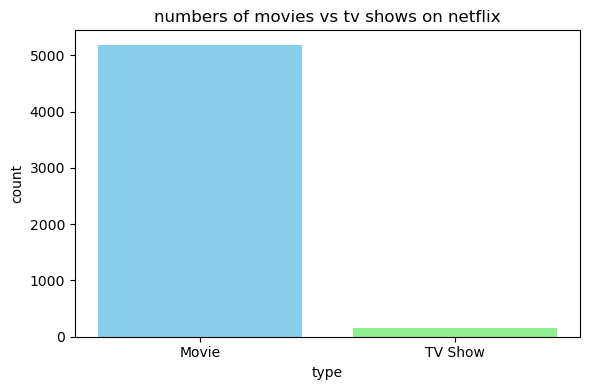

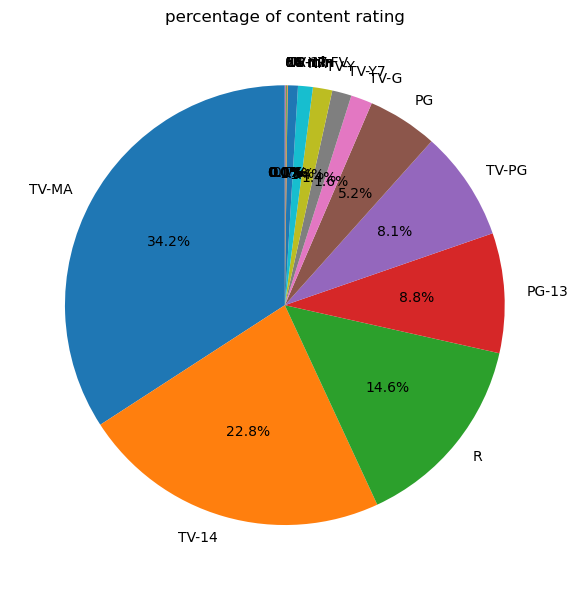

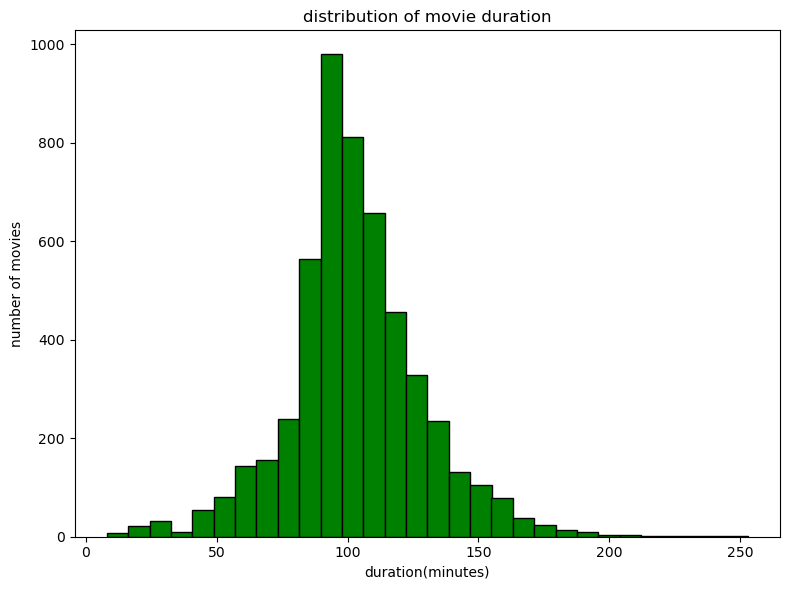

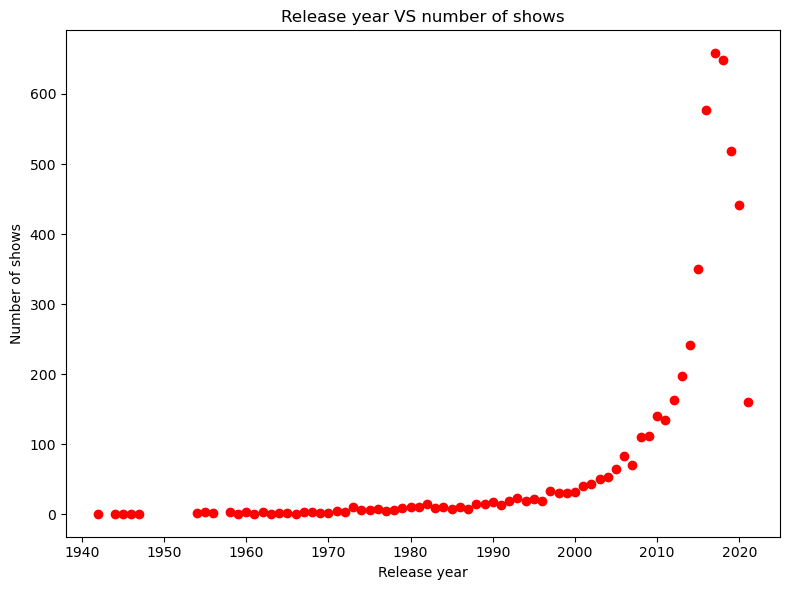

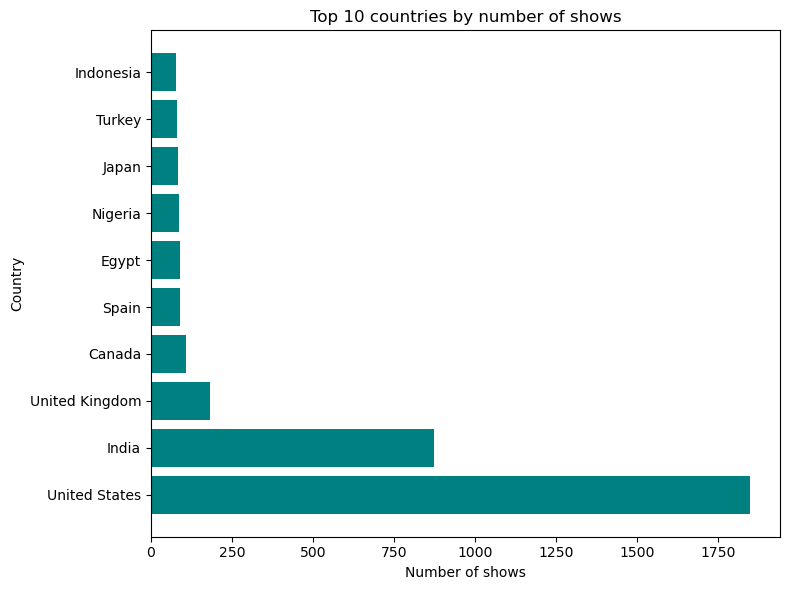

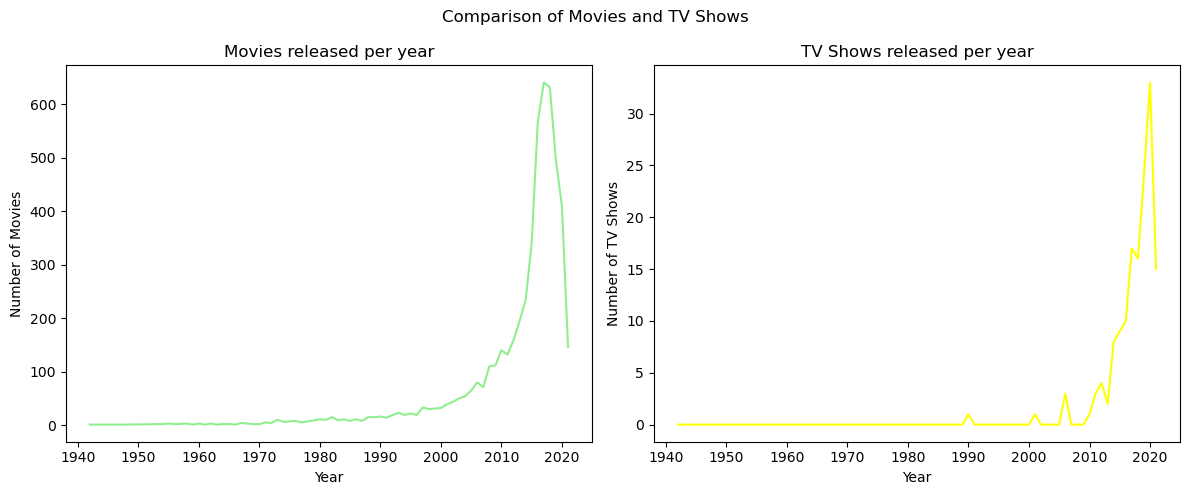

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 

#read the file
df = pd.read_csv("netflix_titles.csv")
print(df)
df = df.dropna(subset = ['show_id','type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'listed_in'])

# bar plot
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color = ['skyblue','lightgreen'])
plt.title('numbers of movies vs tv shows on netflix')
plt.xlabel('type')
plt.ylabel('count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

#pie plot
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels = rating_counts.index, autopct = '%1.1f%%', startangle = 90)
plt.title('percentage of content rating')
plt.tight_layout()
plt.savefig('content_rating_pie.png')
plt.show()

#histogram
movie_df = df[df['type']  == 'Movie'].copy() 
movie_df['duration_int'] = movie_df['duration'].str.replace('min','',regex = False)
movie_df['duration_int'] = pd.to_numeric(movie_df['duration_int'], errors = 'coerce')
movie_df = movie_df.dropna(subset = ['duration_int'])

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins = 30, color = 'green', edgecolor = 'black')

plt.title('distribution of movie duration')
plt.xlabel('duration(minutes)')
plt.ylabel('number of movies')

plt.tight_layout()
plt.savefig('movies_duration_histogram.png')
plt.show()

#scatter plot
release_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.scatter(release_counts.index, release_counts.values, color='red')

plt.title('Release year VS number of shows')
plt.xlabel('Release year')
plt.ylabel('Number of shows')

plt.tight_layout()
plt.savefig('release_year_sactter.png')
plt.show()

#horizontal bar 
country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color = 'teal')
plt.title('Top 10 countries by number of shows')
plt.xlabel('Number of shows')
plt.ylabel('Country')

plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()

#Subplot: Movie vs TV Shows per year

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# 🎬 Movies subplot
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='lightgreen')
ax[0].set_title('Movies released per year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

# 📺 TV Shows subplot
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='yellow')
ax[1].set_title('TV Shows released per year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows')

# Title for whole figure
fig.suptitle('Comparison of Movies and TV Shows')

plt.tight_layout()
plt.savefig('movie_tv_shows_comparison.png')
plt.show()